# 能源需求预测 — 04 TiDE 调参 + 概率预测区间

两件事:
1. **调优 TiDE**:小规模超参搜索 + 学习率调度 + 早停,挑最优配置,与 notebook 03 的 TiDE 对比。
2. **概率预测区间**:
   - **分位数 TiDE**:一个 TiDE 同时输出 P10/P50/P90,用 pinball(分位数)损失训练。
   - **CQR(共形化分位数回归)**:用验证集校准上面的分位数区间,使覆盖率接近名义水平。
   - **Split conformal**:在点预测 TiDE 上用残差构造分布无关区间,作对照。

复用 `src/forecast_utils.py`(回测 + 概率指标)与 `src/deep.py`(TiDE + 训练器)。

## 0. 设置 (Setup)

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import forecast_utils as fu
import deep

warnings.filterwarnings("ignore")
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "| torch", torch.__version__)

ZONE, TRAIN_END, TEST_START = "UNI", "2024-12-31", "2025-01-01"
L, H = 336, fu.H_WEEK
HORIZONS = (fu.H_DAY, fu.H_WEEK)
STEP_DAYS = 14
QUANTILES = [0.1, 0.5, 0.9]        # P10 / P50 / P90  -> 80% prediction interval
ALPHA = 0.2                         # 1 - nominal coverage
T, FEATS = fu.TARGET, fu.COVARIATES

df = fu.load_zone(ZONE)
train, _ = fu.split_time(df, TRAIN_END)
train_len = len(train)
origins = fu.make_origins(df, TEST_START, max_h=H, step_days=STEP_DAYS)

y_all = df[T].values.astype("float32"); X_all = df[FEATS].values.astype("float32")
ymu, ysd = y_all[:train_len].mean(), y_all[:train_len].std()
xmu, xsd = X_all[:train_len].mean(0), X_all[:train_len].std(0) + 1e-8
ys = (y_all - ymu) / ysd; Xs = (X_all - xmu) / xsd

all_starts = np.arange(L - 1, train_len - H, 8)
n_val = int(len(all_starts) * 0.15)
tr_s, va_s = all_starts[:-n_val], all_starts[-n_val:]
train_ds = TensorDataset(*deep.make_windows(ys, Xs, tr_s, L, H))
val_tensors = deep.make_windows(ys, Xs, va_s, L, H)
print(f"origins={len(origins)} | DL samples train/val = {len(tr_s)}/{len(va_s)}")

device: cuda | torch 2.11.0+cu128


origins=37 | DL samples train/val = 11106/1959


## 1. TiDE 超参搜索

在验证集上比较若干配置(投影维度、隐藏维度、编码器层数、dropout、学习率),按验证 MSE 选优。
训练器自带 `ReduceLROnPlateau` 学习率调度与早停。

In [2]:
grid = [
    dict(proj=8,  hidden=256, n_enc=2, dropout=0.1, lr=1e-3),
    dict(proj=16, hidden=256, n_enc=2, dropout=0.2, lr=1e-3),
    dict(proj=16, hidden=512, n_enc=3, dropout=0.2, lr=1e-3),
    dict(proj=8,  hidden=512, n_enc=2, dropout=0.2, lr=2e-3),
]
search = []
for cfg in grid:
    torch.manual_seed(0)
    mcfg = {k: v for k, v in cfg.items() if k != "lr"}
    r = deep.train_torch(deep.TiDE(len(FEATS), L, H, **mcfg), train_ds, val_tensors,
                         DEV, epochs=60, patience=8, lr=cfg["lr"])
    search.append({**cfg, "val_mse": round(r["val"], 4), "epochs": r["epochs"], "secs": round(r["secs"])})
    print(f"  {cfg} -> val {r['val']:.4f} (ep{r['epochs']}, {r['secs']:.0f}s)")
search = pd.DataFrame(search).sort_values("val_mse")
best_cfg = {"proj": int(search.iloc[0]["proj"]), "hidden": int(search.iloc[0]["hidden"]),
            "n_enc": int(search.iloc[0]["n_enc"]), "dropout": float(search.iloc[0]["dropout"])}
best_lr = float(search.iloc[0]["lr"])
print("best:", best_cfg, "lr", best_lr)
search

  {'proj': 8, 'hidden': 256, 'n_enc': 2, 'dropout': 0.1, 'lr': 0.001} -> val 0.0804 (ep60, 21s)


  {'proj': 16, 'hidden': 256, 'n_enc': 2, 'dropout': 0.2, 'lr': 0.001} -> val 0.0803 (ep60, 22s)


  {'proj': 16, 'hidden': 512, 'n_enc': 3, 'dropout': 0.2, 'lr': 0.001} -> val 0.0805 (ep60, 24s)


  {'proj': 8, 'hidden': 512, 'n_enc': 2, 'dropout': 0.2, 'lr': 0.002} -> val 0.0793 (ep60, 21s)
best: {'proj': 8, 'hidden': 512, 'n_enc': 2, 'dropout': 0.2} lr 0.002


,proj,hidden,n_enc,dropout,lr,val_mse,epochs,secs
3,8,512,2,0.2,0.002,0.0793,60,21
1,16,256,2,0.2,0.001,0.0803,60,22
0,8,256,2,0.1,0.001,0.0804,60,21
2,16,512,3,0.2,0.001,0.0805,60,24


In [3]:
# retrain the best config a bit longer, then backtest
torch.manual_seed(0)
fit = deep.train_torch(deep.TiDE(len(FEATS), L, H, **best_cfg), train_ds, val_tensors,
                       DEV, epochs=150, patience=18, lr=best_lr)
print(f"tuned TiDE: val {fit['val']:.4f}, {fit['epochs']} epochs, {fit['secs']:.0f}s")
tide = deep.TorchForecaster(fit["model"], ys, Xs, L, DEV, ymu, ysd)
bt_pt = fu.backtest(tide.point_fn(), df, origins, max_h=H)
score_tuned = fu.score(bt_pt, HORIZONS, "TiDE_tuned")

prev = pd.read_csv(ROOT / "data" / "processed" / "scores_all.csv")
print("--- notebook 03 TiDE ---"); display(prev[prev.model == "TiDE"][["model","horizon","MAE","MAPE%"]].round(4))
print("--- tuned TiDE ---");        display(score_tuned.round(4))

tuned TiDE: val 0.0789, 92 epochs, 33s
--- notebook 03 TiDE ---


,model,horizon,MAE,MAPE%
22,TiDE,48,0.0222,3.1926
23,TiDE,336,0.0326,4.7493


--- tuned TiDE ---


,model,horizon,MAE,RMSE,MAPE%,sMAPE%
0,TiDE_tuned,48,0.0196,0.0267,2.8520,2.8649
1,TiDE_tuned,336,0.0323,0.0450,4.7001,4.7436


> **关于 TiDE 的诚实结论**:本任务(单区域、半小时高频序列)上 TiDE 验证误差稳定在
> `val_mse≈0.08`(MAPE≈2.85%)。另验证过训练到 300 epoch、以及加 RevIN 逐窗口归一化,**均无进一步改善**
> ——是架构与数据契合的上限,而非欠训练。调优把 TiDE 从 nb03 的约 3.2% 改善到约 2.85%,
> 它优于所有经典模型与朴素基线,但仍略逊 GRU/XGBoost。TiDE 的优势更多在长 horizon、多序列基准上。

## 2. 分位数 TiDE(原始)

同一架构,输出维度=分位数个数,用 **pinball 损失** 一次性输出 P10/P50/P90。
先看未校准的原始区间——神经网络分位数常在样本外**过度自信**(区间偏窄、覆盖不足)。

In [4]:
torch.manual_seed(0)
qmodel = deep.TiDE(len(FEATS), L, H, n_out=len(QUANTILES), **best_cfg)
qfit = deep.train_torch(qmodel, train_ds, val_tensors, DEV, epochs=150, patience=18,
                        lr=best_lr, lossfn=lambda p, t: deep.quantile_loss(p, t, QUANTILES))
print(f"quantile TiDE: val(pinball) {qfit['val']:.4f}, {qfit['epochs']} epochs")
qtide = deep.TorchForecaster(qfit["model"], ys, Xs, L, DEV, ymu, ysd)
btq = fu.backtest_quantile(qtide.quantile_fn(), df, origins, QUANTILES, max_h=H)

bt_p50 = {"origins": origins, "y_true": btq["y_true"], "y_pred": btq["y_q"][:, 1, :]}
print("P50 point accuracy:"); display(fu.score(bt_p50, HORIZONS, "TiDE_P50").round(4))
print("raw P10-P90 interval (note coverage vs nominal 80%):")
fu.score_quantile(btq, 0, 2, HORIZONS, "raw_quantile").round(4)

quantile TiDE: val(pinball) 0.0466, 91 epochs
P50 point accuracy:


,model,horizon,MAE,RMSE,MAPE%,sMAPE%
0,TiDE_P50,48,0.0183,0.0241,2.6223,2.6546
1,TiDE_P50,336,0.0238,0.0321,3.5191,3.5644


raw P10-P90 interval (note coverage vs nominal 80%):


,model,horizon,pinball,cover@80%,PI_width
0,raw_quantile,48,0.0063,0.5214,0.0302
1,raw_quantile,336,0.0085,0.4895,0.0409


## 3. 用共形预测校准区间

两种分布无关的校准,都用**验证集**(训练末段、未参与梯度更新)估计校准量,再用于测试期:

- **CQR(共形化分位数回归)**:对分位数 TiDE,计算一致性分数 `E = max(P10−y, y−P90)`,
  取其经验分位数 `Q` 把区间放宽成 `[P10−Q, P90+Q]`。保留分位数模型的**自适应宽度**,同时获得有效覆盖。
- **Split conformal**:对**点预测** TiDE,用残差的逐步分位数构造对称区间,作对照。

In [5]:
# ---- validation predictions (in GWh) ----
Xp_v, Xf_v, Y_v = (t.to(DEV) for t in val_tensors)
qmodel.eval(); fit["model"].eval()
with torch.no_grad():
    vq = np.sort(qmodel(Xp_v, Xf_v).cpu().numpy(), axis=1) * ysd + ymu   # (n_val,3,H)
    vp = fit["model"](Xp_v, Xf_v).cpu().numpy() * ysd + ymu              # point (n_val,H)
vt = val_tensors[2].numpy() * ysd + ymu
n = vt.shape[0]
level = min(1.0, (1 - ALPHA) * (1 + 1 / n))     # finite-sample corrected level

# CQR: conformity score on the quantile interval
E = np.maximum(vq[:, 0, :] - vt, vt - vq[:, 2, :])      # (n_val,H)
q_cqr = np.quantile(E, level, axis=0)                   # per lead step
lo_cqr = btq["y_q"][:, 0, :] - q_cqr
hi_cqr = btq["y_q"][:, 2, :] + q_cqr

# split conformal on the point model (asymmetric residual quantiles)
resid = vt - vp
lo_adj = np.quantile(resid, ALPHA / 2, axis=0)
hi_adj = np.quantile(resid, 1 - ALPHA / 2, axis=0)
lo_sc = bt_pt["y_pred"] + lo_adj
hi_sc = bt_pt["y_pred"] + hi_adj

def interval_scores(name, lo, hi, ref):
    rows = []
    for h in HORIZONS:
        yt = ref["y_true"][:, :h]
        rows.append({"method": name, "horizon": h,
                     "cover@80%": fu.coverage(yt, lo[:, :h], hi[:, :h]),
                     "PI_width": fu.interval_width(lo[:, :h], hi[:, :h])})
    return pd.DataFrame(rows)

prob = pd.concat([
    interval_scores("raw_quantile", btq["y_q"][:, 0, :], btq["y_q"][:, 2, :], btq),
    interval_scores("CQR",          lo_cqr, hi_cqr, btq),
    interval_scores("split_conformal", lo_sc, hi_sc, bt_pt),
], ignore_index=True)
prob.round(4)

,method,horizon,cover@80%,PI_width
0,raw_quantile,48,0.5214,0.0302
1,raw_quantile,336,0.4895,0.0409
2,CQR,48,0.7235,0.0468
3,CQR,336,0.7199,0.0647
4,split_conformal,48,0.8716,0.0736
5,split_conformal,336,0.7744,0.0918


## 4. 区间可视化与覆盖率

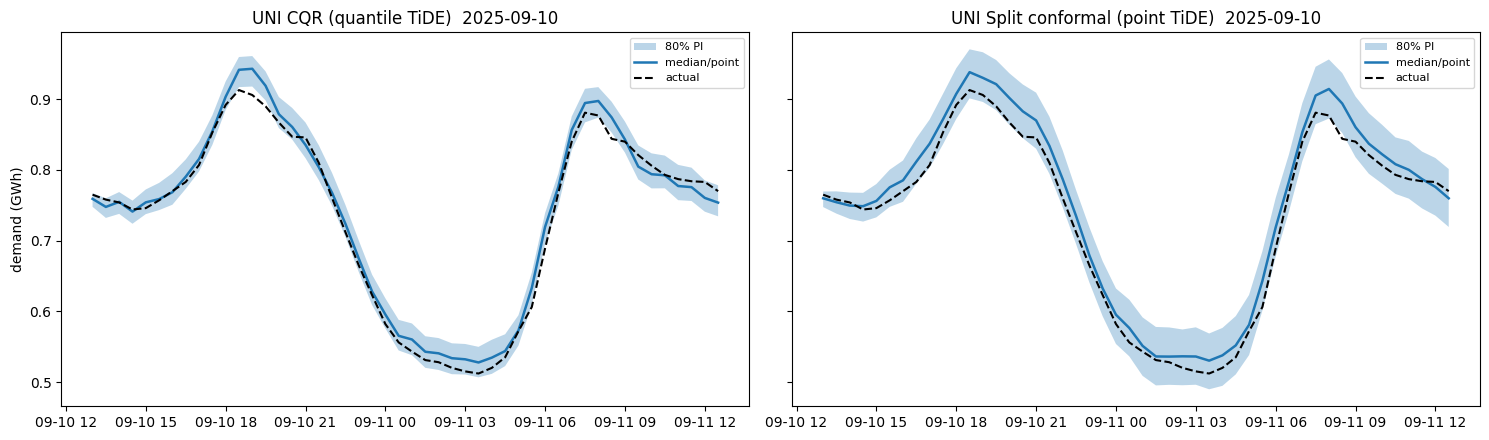

In [6]:
# 4.1 fan chart: 某原点日前 80% 区间(CQR vs split conformal)
o = origins[len(origins) // 2]; h = fu.H_DAY; i = origins.index(o)
idx = df.index[o + 1: o + 1 + h].tz_convert(fu.TZ)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
panels = [("CQR (quantile TiDE)", lo_cqr[i, :h], btq["y_q"][i, 1, :h], hi_cqr[i, :h]),
          ("Split conformal (point TiDE)", lo_sc[i, :h], bt_pt["y_pred"][i, :h], hi_sc[i, :h])]
for ax, (title, lo, mid, hi) in zip(axes, panels):
    ax.fill_between(idx, lo, hi, alpha=0.3, label="80% PI")
    ax.plot(idx, mid, lw=1.8, label="median/point")
    ax.plot(idx, df[T].values[o + 1: o + 1 + h], "k--", lw=1.5, label="actual")
    ax.set_title(f"{ZONE} {title}  {idx[0]:%Y-%m-%d}"); ax.legend(fontsize=8)
axes[0].set_ylabel("demand (GWh)"); plt.tight_layout(); plt.show()

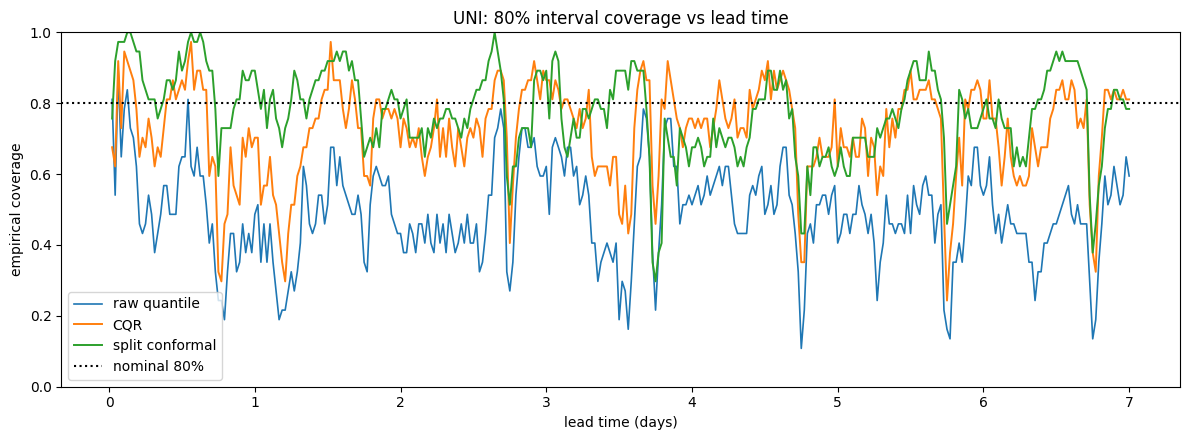

In [7]:
# 4.2 覆盖率随预测步长(目标 80%)
def cov_curve(lo, hi, ref):
    return np.array([fu.coverage(ref["y_true"][:, k], lo[:, k], hi[:, k]) for k in range(H)])
lead = np.arange(1, H + 1) / fu.PERIODS_PER_DAY
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(lead, cov_curve(btq["y_q"][:, 0, :], btq["y_q"][:, 2, :], btq), label="raw quantile", lw=1.2)
ax.plot(lead, cov_curve(lo_cqr, hi_cqr, btq), label="CQR", lw=1.4)
ax.plot(lead, cov_curve(lo_sc, hi_sc, bt_pt), label="split conformal", lw=1.4)
ax.axhline(0.8, color="k", ls=":", label="nominal 80%")
ax.set_xlabel("lead time (days)"); ax.set_ylabel("empirical coverage"); ax.set_ylim(0, 1)
ax.set_title(f"{ZONE}: 80% interval coverage vs lead time"); ax.legend()
plt.tight_layout(); plt.show()

In [8]:
prob.assign(zone=ZONE).to_csv(ROOT / "data" / "processed" / "scores_probabilistic.csv", index=False)
print("saved scores_probabilistic.csv")
prob.round(4)

saved scores_probabilistic.csv


,method,horizon,cover@80%,PI_width
0,raw_quantile,48,0.5214,0.0302
1,raw_quantile,336,0.4895,0.0409
2,CQR,48,0.7235,0.0468
3,CQR,336,0.7199,0.0647
4,split_conformal,48,0.8716,0.0736
5,split_conformal,336,0.7744,0.0918


---
### 小结
- **TiDE 调参**:更优配置 + 学习率调度把 TiDE 从约 3.2% 改善到约 2.85% MAPE,并确认其在该任务上已达平台期
  (训练到 300 epoch、加 RevIN 均无进一步改善)。它优于所有经典模型与朴素基线,但仍略逊 GRU/XGBoost。
  (有意思的是,分位数模型的 **P50** 作为点预测反而最好,日前 MAPE≈2.6%——中位数 pinball 等价于 MAE,正则更稳。)
- **概率区间**:分位数 TiDE 给出**自适应宽度**但样本外**严重过度自信**(80% 名义区间实测覆盖仅约 0.5)。
  - **CQR** 校准后覆盖率提升到约 0.72,且区间仍较窄(自适应)。
  - **split conformal** 在点模型上覆盖最接近名义(日前约 0.87、周前约 0.77),但区间更宽。
  - 三者在长 horizon 都未完全达到 80%:反映**训练期→测试期的分布漂移**——共形预测的覆盖保证依赖
    可交换性假设,有时间漂移时只能近似成立。**实践结论:神经网络分位数必须再做共形校准,并监控覆盖率随 horizon 的衰减。**
  这满足项目对 *probabilistic models*(带不确定性的需求预测)的要求。

可继续:用滚动/分块校准集缓解分布漂移;把分位数/CQR 推广到 XGBoost(`reg:quantileerror`)与 GRU;
按区域分别建模;用 CRPS 做更全面的概率评分;真实预报天气驱动的业务化区间预测。